In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb

import sys
sys.path.append('../../src/utils/')
sys.path.append('../../src/benchmark/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small, xcit_medium
from train_functions import train_epochs
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid
from RotateConvolution import RotateConv2d

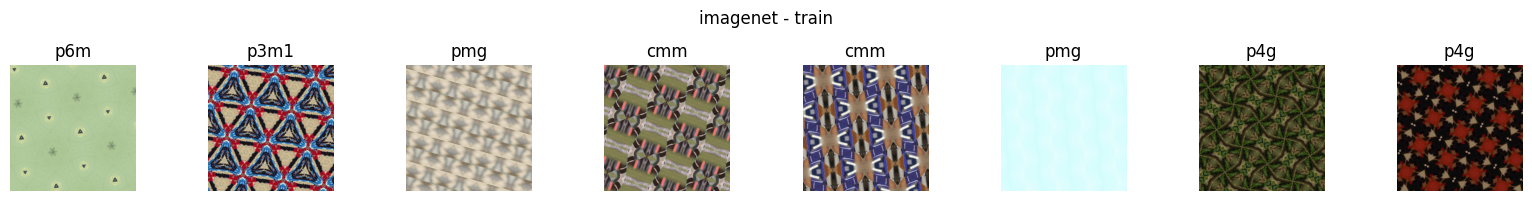

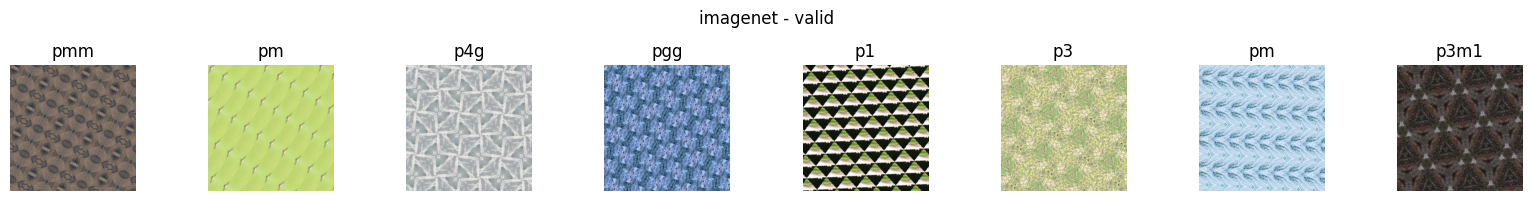

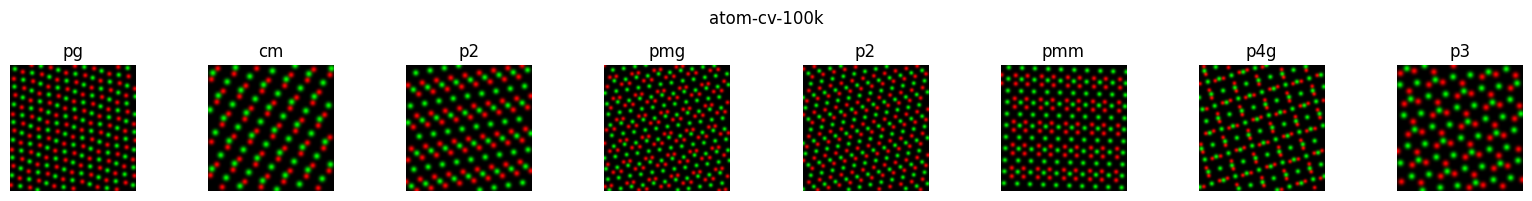

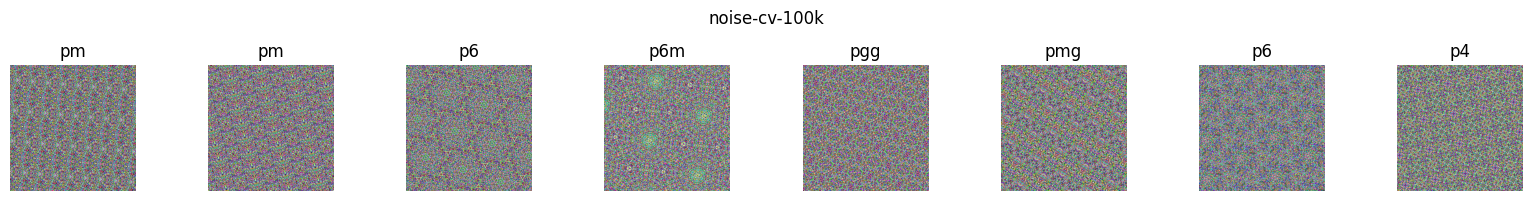

In [2]:
num_workers = 2
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

h5_file = '/mnt/raid0/yichen/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5'
imagenet_ds = hdf5_dataset(h5_file, folder='imagenet', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

# imagenet - train
train_dl = DataLoader(train_ds, batch_size=800, shuffle=False, num_workers=num_workers)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

# imagenet - valid
valid_dl = DataLoader(valid_ds, batch_size=1024, shuffle=False, num_workers=num_workers)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom-cv-100k
cv_atom_ds_100k = hdf5_dataset(h5_file, folder='atom', transform=transforms.ToTensor())
cv_atom_dl_100k = DataLoader(cv_atom_ds_100k, batch_size=1024, shuffle=True, num_workers=num_workers)
viz_dataloader(cv_atom_dl_100k, label_converter=label_converter, title='atom-cv-100k')

# noise-cv-100k
cv_noise_ds_100k = hdf5_dataset(h5_file, folder='noise', transform=transforms.ToTensor())
cv_noise_dl_100k = DataLoader(cv_noise_ds_100k, batch_size=1024, shuffle=True, num_workers=num_workers)
viz_dataloader(cv_noise_dl_100k, label_converter=label_converter, title='noise-cv-100k')

### keep original

In [3]:
model = resnet50_(in_channels=3, n_classes=17)
model.conv1 = RotateConv2d(3, 64, kernel_size=7, padding=3, stride=2, symmetries=[2,3,4,6], keep_original=True)
model.layer1[0].conv1 = RotateConv2d(64, 64, kernel_size=1, padding=0, stride=1, symmetries=[2,3,4,6], keep_original=True)
print(model(torch.randn(2,3,256,256)).shape)

torch.Size([2, 17])


In [4]:
model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])
device = torch.device('cuda:0')

In [5]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'ResNet50_rot2346f_keep_original_conv2d-100K_subset'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [6]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_100k, cv_noise_dl_100k], cv_name_list=['cv_atom_100k', 'cv_noise_100k'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


100%|██████████| 100/100 [00:46<00:00,  2.13it/s]


Training: Loss: 3.0804, Accuracy: 5.9875%.


100%|██████████| 20/20 [00:11<00:00,  1.72it/s]


Validation : Loss : 2.8530, Accuracy: 6.4450%, Time: 0.19mins
Validation: Loss: 2.8530, Accuracy: 6.4450%.


...

Validation : Loss : 0.6482, Accuracy: 87.5050%, Time: 0.19mins
Validation: Loss: 0.6482, Accuracy: 87.5050%.


100%|██████████| 98/98 [00:53<00:00,  1.83it/s]


Validation : Loss : 6.8724, Accuracy: 30.0580%, Time: 0.89mins
cv_atom_100k: Loss: 6.8724, Accuracy: 30.0580%.


100%|██████████| 100/100 [00:54<00:00,  1.83it/s]


Validation : Loss : 4.9376, Accuracy: 19.1931%, Time: 0.91mins
cv_noise_100k: Loss: 4.9376, Accuracy: 19.1931%.


### rot 2 only

In [7]:
model = resnet50_(in_channels=3, n_classes=17)
model.conv1 = RotateConv2d(3, 64, kernel_size=7, padding=3, stride=2, symmetries=[2])
model.layer1[0].conv1 = RotateConv2d(64, 64, kernel_size=1, padding=0, stride=1, symmetries=[2])
print(model(torch.randn(2,3,256,256)).shape)

torch.Size([2, 17])


In [8]:
model = torch.nn.DataParallel(model, device_ids=[8,9])
device = torch.device('cuda:8')

In [9]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'ResNet50_rot2f_conv2d-100K_subset'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


cv_atom_100k_acc,▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄█▄▄▄▄▄▄▄▁▄▄▄▄▄▄▄▄▄▄▄▄▄▄
cv_atom_100k_loss,█▂▂▄█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cv_noise_100k_acc,██████████████▁████████████▄████████████
cv_noise_100k_loss,█▂▂▄█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_acc,▁▁▁▁▁▁▃▄▅▆▆▆▆▇▇▇▇▇▇▇▇███████████████████
train_loss,█████▇▆▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
valid_acc,▆█▄▆▅▄▅▅▅▆▃▂▄▂▅▅▂▃▇▃▅▆▆▂▄▃▁▇▂▆▇▃▆▃▄▆▆▅▄▄
valid_loss,█▂▂▇█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cv_atom_100k_acc,0.05886
cv_atom_100k_loss,8.15508


In [10]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_100k, cv_noise_dl_100k], cv_name_list=['cv_atom_100k', 'cv_noise_100k'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


Training: Loss: 3.0651, Accuracy: 6.0237%.


100%|██████████| 20/20 [00:10<00:00,  1.85it/s]


Validation : Loss : 1936.8185, Accuracy: 5.7550%, Time: 0.18mins
Validation: Loss: 1936.8185, Accuracy: 5.7550%.


...

Validation : Loss : 9.3255, Accuracy: 5.8300%, Time: 0.18mins
Validation: Loss: 9.3255, Accuracy: 5.8300%.


100%|██████████| 98/98 [00:46<00:00,  2.12it/s]


Validation : Loss : 9.2176, Accuracy: 5.8860%, Time: 0.77mins
cv_atom_100k: Loss: 9.2176, Accuracy: 5.8860%.


100%|██████████| 100/100 [00:46<00:00,  2.17it/s]


Validation : Loss : 9.0113, Accuracy: 5.8824%, Time: 0.77mins
cv_noise_100k: Loss: 9.0113, Accuracy: 5.8824%.


### rot 2,3,4,6 add regularization: l2=0.01, dropout=0.8

In [7]:
model = resnet50_(in_channels=3, n_classes=17, dropout=0.8)
model.conv1 = RotateConv2d(3, 64, kernel_size=7, padding=3, stride=2)
model.layer1[0].conv1 = RotateConv2d(64, 64, kernel_size=1, padding=0, stride=1)
print(model(torch.randn(2,3,256,256)).shape)

torch.Size([2, 17])


In [8]:
model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])
device = torch.device('cuda:0')

In [9]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'ResNet50_rot_conv2d_reg-100K_subset'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


cv_atom_100k_acc,▁▁▁▂▃▄▅▅▆▆▇▇▇▇▇█▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
cv_atom_100k_loss,▁▁▁▁▁▁▂▂▃▄▄▃▄▃▄▄▆▅▆▆▆▇█▇███▇██▇█████████
cv_noise_100k_acc,▁▁▁▂▁▃▃▃▄▅▄▆▇▅▆▇▅▇▇▆▅▆▆▆▅▇▄▆▇███████████
cv_noise_100k_loss,▂▂▂▁▂▁▂▁▂▃▃▂▁▂▂▂▃▂▃▃▅▄▄▄▅▅█▆▄▄▄▄▄▄▄▄▄▄▄▄
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_acc,▁▁▁▁▁▂▄▅▅▆▆▆▇▇▇▇▇▇▇▇████████████████████
train_loss,████▇▆▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
valid_acc,▁▁▁▁▂▂▁▂▂▂▁▇▃▂▃▃▃▂▂▂▂▂█▃▃▂▃▃▂▂▂▃▃█▃▃▂▂▂▂
valid_loss,▄▄▄▃▃▄▄▅▅▄▅▁▅▄▅▅▆▄▅▅▆▅▁▇█▆▇▇▅▅▆██▁██▆▅▅▆
cv_atom_100k_acc,0.30058
cv_atom_100k_loss,6.87242


In [10]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_100k, cv_noise_dl_100k], cv_name_list=['cv_atom_100k', 'cv_noise_100k'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


100%|██████████| 100/100 [01:10<00:00,  1.41it/s]


Training: Loss: 3.4365, Accuracy: 5.9775%.


100%|██████████| 20/20 [00:11<00:00,  1.77it/s]


Validation : Loss : 7276.9763, Accuracy: 5.8300%, Time: 0.19mins
Validation: Loss: 7276.9763, Accuracy: 5.8300%.


...

Validation : Loss : 0.7155, Accuracy: 74.2050%, Time: 0.18mins
Validation: Loss: 0.7155, Accuracy: 74.2050%.


100%|██████████| 98/98 [00:51<00:00,  1.90it/s]


Validation : Loss : 3.1784, Accuracy: 27.3000%, Time: 0.86mins
cv_atom_100k: Loss: 3.1784, Accuracy: 27.3000%.


100%|██████████| 100/100 [00:52<00:00,  1.90it/s]


Validation : Loss : 4.4874, Accuracy: 7.0157%, Time: 0.88mins
cv_noise_100k: Loss: 4.4874, Accuracy: 7.0157%.


In [11]:
lr = 1e-3
start = 50
epochs = 150

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_100k, cv_noise_dl_100k], cv_name_list=['cv_atom_100k', 'cv_noise_100k'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../saved_models/{NAME}/', tracking=True)

Epoch: 51/200


100%|██████████| 100/100 [01:23<00:00,  1.20it/s]


Training: Loss: 0.8437, Accuracy: 66.7137%.


100%|██████████| 20/20 [00:15<00:00,  1.28it/s]


Validation : Loss : 0.7392, Accuracy: 72.1300%, Time: 0.26mins
Validation: Loss: 0.7392, Accuracy: 72.1300%.


...

Validation : Loss : 0.2440, Accuracy: 93.5150%, Time: 0.20mins
Validation: Loss: 0.2440, Accuracy: 93.5150%.


100%|██████████| 98/98 [00:57<00:00,  1.71it/s]


Validation : Loss : 3.8323, Accuracy: 29.8500%, Time: 0.95mins
cv_atom_100k: Loss: 3.8323, Accuracy: 29.8500%.


100%|██████████| 100/100 [00:54<00:00,  1.83it/s]


Validation : Loss : 2.5826, Accuracy: 33.8441%, Time: 0.91mins
cv_noise_100k: Loss: 2.5826, Accuracy: 33.8441%.


### rot 2, 3, 4, 6

In [3]:
model = resnet50_(in_channels=3, n_classes=17)
model.conv1 = RotateConv2d(3, 64, kernel_size=7, padding=3, stride=2)
model.layer1[0].conv1 = RotateConv2d(64, 64, kernel_size=1, padding=0, stride=1)
print(model(torch.randn(2,3,256,256)).shape)

torch.Size([2, 17])


In [4]:
model = torch.nn.DataParallel(model, device_ids=[8,9])
device = torch.device('cuda:8')

In [5]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'ResNet50_rot_conv2d-100K_subset'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='preprocess', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [6]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_100k, cv_noise_dl_100k], cv_name_list=['cv_atom_100k', 'cv_noise_100k'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


100%|██████████| 100/100 [01:32<00:00,  1.08it/s]


Training: Loss: 3.0606, Accuracy: 6.1175%.


100%|██████████| 20/20 [00:10<00:00,  1.84it/s]


Validation : Loss : 6603.4008, Accuracy: 5.8300%, Time: 0.18mins
Validation: Loss: 6603.4008, Accuracy: 5.8300%.


...

Validation : Loss : 8.0170, Accuracy: 5.8300%, Time: 0.18mins
Validation: Loss: 8.0170, Accuracy: 5.8300%.


100%|██████████| 98/98 [00:50<00:00,  1.96it/s]


Validation : Loss : 8.1551, Accuracy: 5.8860%, Time: 0.83mins
cv_atom_100k: Loss: 8.1551, Accuracy: 5.8860%.


100%|██████████| 100/100 [00:50<00:00,  1.97it/s]


Validation : Loss : 8.0503, Accuracy: 5.8824%, Time: 0.84mins
cv_noise_100k: Loss: 8.0503, Accuracy: 5.8824%.
